# Amazing International Airlines Inc
------
Group 12
Luis Mendes 20221949
Margarida Mourives 20221809
Simon 
Veronica Mendes 20221944
----
# Exploratory Data Analysis (EDA) 
## Summary

(FALTA)

### <font>Index </font> <a class="anchor" id='toc'></a> 
- [0. Metadata](#0-metadata)
- 


# QUESTIONS

+ If 2 persons had the same customer loyalty but they are different persons, we delete them since we cannot know which one is the real one, is ok? them we delete also the rows that dont have any correspondance. (DELETE OBS)
+ Is good to create variables by month or month-year (to many columns and values tahn the actual usefulness of it). (ONKY MONTH FOR ANALYSIS OR USE FLIGHTS DATASET)
+ We need to create the dummies variables right now? or that will be on the second part (NO PREPROCESING; OUTLIERS REMOVAL ;SCALING; ECT ON THIS PHASe)

## Imports

In [8]:
#imports 
#(create utils file for functions)
import pandas as pd
import numpy as np
# Resto de imports (visualization, etc)
import matplotlib.pyplot as plt
import seaborn as sns

from math import ceil

pd.set_option('display.max_columns', None)

In [2]:
df_AIAI_Customers_Complete = pd.read_csv('../../data/DM_AIAI_CustomerDB.csv')
df_AIAI_Customers = df_AIAI_Customers_Complete.copy()

df_AIAI_Flights_Complete = pd.read_csv('../../data/DM_AIAI_FlightsDB.csv')
df_AIAI_Flights = df_AIAI_Flights_Complete.copy()

## 0. Metadata <a class="anchor" id='#0-metadata'></a>

DM_AIAI_CustomerDB.csv

- *Loyalty#* - Unique customer identifier for loyalty program members
- *First Name* - Customer’s first name
- *Last Name* - Customer’s last name
- *Customer Name* - Customer’s full name (concatenated)
- *Country* - Customer’s country of residence
- *Province or State* - Customer’s province or state
- *City* - Customer’s city of residence
- *Latitude* - Geographic latitude coordinate of customer location
- *Longitude* - Geographic longitude coordinate of customer location
- *Postal code* - Customer’s postal/ZIP code
- *Gender* - Customer’s gender
- *Education* - Customer’s highest education level (Bachelor, College, etc.)
- *Location Code* - Urban/Suburban/Rural classification of customer residence
- *Income* - Customer’s annual income
- *Marital Status* - Customer’s marital status (Married, Single, Divorced)
- *LoyaltyStatus* - Current tier status in loyalty program (Star > Nova > Aurora)
- *EnrollmentDateOpening* - Date when customer joined the loyalty program
- *CancellationDate* - Date when customer left the program
- *Customer Lifetime Value* - Total calculated monetary value of customer relationship
- *EnrollmentType* - Method of joining loyalty program

DM_AIAI_FlightsDB.csv


- *Loyalty#* - Unique customer identifier linking to CustomerDB
- *Year* - Year of flight activity record
- *Month* - Month of flight activity record (1-12)
- *YearMonthDate* - First day of the month for the activity period
- *NumFlights* -  Total number of flights taken by customer in the month
- *NumFlightsWithCompanions* - Number of flights where customer traveled with companions
- *DistanceKM* - Total distance traveled in kilometers for the month
- *PointsAccumulated* - Loyalty points earned by customer during the month
- *PointsRedeemed* - Loyalty points spent/redeemed by customer during the month
- *DollarCostPointsRedeemed* - Dollar value of points redeemed during the month


## Data Exploration

#### **Customers DataFrame**

In [15]:
df_AIAI_Customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


Delete the first column that is not an index nor in the metadata

In [16]:
df_AIAI_Customers.drop(columns=['Unnamed: 0'], inplace=True)

Now we will verify the different types of data and the missing values

In [17]:
df_AIAI_Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loyalty#                 16921 non-null  int64  
 1   First Name               16921 non-null  object 
 2   Last Name                16921 non-null  object 
 3   Customer Name            16921 non-null  object 
 4   Country                  16921 non-null  object 
 5   Province or State        16921 non-null  object 
 6   City                     16921 non-null  object 
 7   Latitude                 16921 non-null  float64
 8   Longitude                16921 non-null  float64
 9   Postal code              16921 non-null  object 
 10  Gender                   16921 non-null  object 
 11  Education                16921 non-null  object 
 12  Location Code            16921 non-null  object 
 13  Income                   16901 non-null  float64
 14  Marital Status        

We have on total 16921 observations (customers).

The data types are correct on almost every column, meaning that the values stores at least are of the data types that they are supouse to be.

It is only needed to change the data types of the date columns (EnrollmentDateOpening, CancellationDate).

In [18]:
df_AIAI_Customers.isna().sum()

Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

We have missing values in our data in the columns: Income (20 records, 0.11%), CancellationDate (14611 records, 86%), Customer Lifetime Value (20 records, 0.11%). We will evaluate and them decide if we can remove those observations (since they are a small proportion of the hole dataset) or do imputation.

Probably people do not fill the income because they do not want us to know how much they earn, so we cuold perform an imputation with similar data points.

The higher number of missing values in CancellationDate may be because not many people canceled and didn't leave the program. So it is not an error.

To know what to do with Customer Lifetime Value, we will need to see the relation that exits with the flights data, if the customer have some records if better not to remove and instead do some imputation based on similar points (performing imputation).

In [19]:
# Identify rows with more than one missing value in 'Income' and 'Customer Lifetime Value'
df_AIAI_Customers[df_AIAI_Customers[["Income", "Customer Lifetime Value"]].isna().sum(axis=1) > 1]

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard
16906,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.706878,-79.437412,P6D 6N2,male,College,Suburban,NaN,Single,Star,3/27/2021,3/27/2021,NaN,Standard
16907,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.701475,-120.181716,W6H 0Z7,female,College,Suburban,NaN,Married,Star,1/27/2015,1/27/2015,NaN,Standard
16908,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.365906,-75.723181,B2F 3E1,female,College,Rural,NaN,Married,Star,5/5/2016,5/5/2016,NaN,Standard
16909,999995,Liam,Wong,Liam Wong,Canada,Ontario,Ottawa,45.471557,-75.704868,B3A 2R0,female,College,Suburban,NaN,Married,Star,3/2/2020,3/2/2020,NaN,Standard
16910,999996,Isabella,Ross,Isabella Ross,Canada,Ontario,Toronto,43.690489,-79.436758,B4W 4M6,female,Bachelor,Suburban,NaN,Single,Star,9/14/2018,9/14/2018,NaN,Standard


In [20]:
# See if all 20 rows with missing are misisng on both values in 'Income' and 'Customer Lifetime Value' 
df_AIAI_Customers[df_AIAI_Customers[["Income", "Customer Lifetime Value"]].isna().sum(axis=1) > 1].info()
# Awnser: Yes

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 16901 to 16920
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loyalty#                 20 non-null     int64  
 1   First Name               20 non-null     object 
 2   Last Name                20 non-null     object 
 3   Customer Name            20 non-null     object 
 4   Country                  20 non-null     object 
 5   Province or State        20 non-null     object 
 6   City                     20 non-null     object 
 7   Latitude                 20 non-null     float64
 8   Longitude                20 non-null     float64
 9   Postal code              20 non-null     object 
 10  Gender                   20 non-null     object 
 11  Education                20 non-null     object 
 12  Location Code            20 non-null     object 
 13  Income                   0 non-null      float64
 14  Marital Status           2

In [21]:
# Identify rows when 'EnrollmentDateOpening' is the same as 'CancellationDate'
df_AIAI_Customers[df_AIAI_Customers["EnrollmentDateOpening"] == df_AIAI_Customers["CancellationDate"] ]

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
3153,488724,Rayford,Vogus,Rayford Vogus,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,male,Bachelor,Suburban,36495.0,Married,Aurora,1/5/2016,1/5/2016,10629.22,Standard
12237,871455,Gemma,Gadbois,Gemma Gadbois,Canada,Alberta,Calgary,51.048615,-114.070850,T3E 2V9,male,Doctor,Suburban,16269.0,Divorced,Star,6/18/2020,6/18/2020,3211.07,Standard
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard
16906,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.706878,-79.437412,P6D 6N2,male,College,Suburban,NaN,Single,Star,3/27/2021,3/27/2021,NaN,Standard
16907,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.701475,-120.181716,W6H 0Z7,female,College,Suburban,NaN,Married,Star,1/27/2015,1/27/2015,NaN,Standard
16908,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.365906,-75.723181,B2F 3E1,female,College,Rural,NaN,Married,Star,5/5/2016,5/5/2016,NaN,Standard


When the customer has the missing on the income variable, it also do not have Lifetime Value, and they canceled the suscription on the same day, meaning these are persons that are not really customers. At this point the aproach of remove those observations is the better.

Is important to say that are 2 customers that enrolled and canceled on the same day but they have some monetary value, meaning that they only purchased on 1 day, but they are customers (loyalty#: 488724 and 871455).

In [22]:
df_AIAI_Flights[df_AIAI_Flights["Loyalty#"].isin([488724,871455])].describe(include="all")

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,72.000000,72.000000,72.000000,72,72.0,72.0,72.0,72.0,72.0,72.0
unique,NaN,NaN,NaN,36,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,6/1/2020,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,680089.500000,2020.000000,6.500000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
std,192708.432265,0.822226,3.476278,NaN,0.0,0.0,0.0,0.0,0.0,0.0
min,488724.000000,2019.000000,1.000000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
25%,488724.000000,2019.000000,3.750000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
50%,680089.500000,2020.000000,6.500000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
75%,871455.000000,2021.000000,9.250000,NaN,0.0,0.0,0.0,0.0,0.0,0.0


We will also drop these two customers since they dont have any real records of flights (no variance on their transactions)

**Duplicates**

In [23]:
df_AIAI_Customers.duplicated().sum()
# No duplicate rows found

np.int64(0)

In [24]:
df_AIAI_Customers.duplicated(subset=['Loyalty#'], keep=False).sum()
# 327 duplicate Loyalty# values found

np.int64(327)

In [25]:
duplicates_loyalty_Customers_mask = df_AIAI_Customers.duplicated(subset=['Loyalty#'], keep=False)
df_AIAI_Customers[duplicates_loyalty_Customers_mask].sort_values(['Loyalty#'])

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
2668,101902,Yi,Nesti,Yi Nesti,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,female,Bachelor,Urban,79090.0,Married,Aurora,3/19/2020,NaN,8609.16,Standard
1646,101902,Hans,Schlottmann,Hans Schlottmann,Canada,Ontario,London,42.984924,-81.245277,M5B 3E4,female,College,Rural,0.0,Married,Aurora,1/7/2020,NaN,6265.34,Standard
700,106001,Ivette,Peifer,Ivette Peifer,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,female,High School or Below,Suburban,10037.0,Single,Star,1/11/2016,NaN,4914.04,Standard
15988,106001,Maudie,Hyland,Maudie Hyland,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,female,Master,Suburban,14973.0,Divorced,Star,7/16/2015,NaN,12168.74,Standard
9413,106509,Ardelia,Whitehorse,Ardelia Whitehorse,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Rural,30915.0,Married,Nova,4/25/2020,10/7/2021,16727.77,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10626,989528,Sadie,Orejel,Sadie Orejel,Canada,Alberta,Edmonton,53.544388,-113.490930,T9G 1W3,male,Bachelor,Suburban,83772.0,Divorced,Star,4/1/2015,NaN,2453.41,Standard
9890,990512,Magda,Sopher,Magda Sopher,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,10/21/2018,NaN,1904.00,Standard
14478,990512,Ione,Snowden,Ione Snowden,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,female,College,Urban,0.0,Single,Star,8/20/2021,NaN,6870.61,Standard
6981,992168,Frederick,Samaha,Frederick Samaha,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,male,High School or Below,Suburban,22906.0,Married,Nova,9/26/2015,NaN,5746.33,Standard


We will drop these records since there are people with the same Loyalty number and different characteristics, and we do not know which is the "real person", and since we need to use that loyalty number to identify the customer in the other dataset we will drop them (are only 327 rows out of 16921, so it is only 1.93% of the dataset).

And we can put as index colunm the Loyalty number since now we know that will be unique.

**Inconsistencies**

In [26]:
df_AIAI_Customers[df_AIAI_Customers['CancellationDate'] == "2/29/2019"]
# We found that there is a wrong date format, since that day doesnt exist, we will change it to 2/28/2019

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
8840,314558,Retta,Pauley,Retta Pauley,Canada,Quebec,Montreal,45.501690,-73.567253,H4G 3T4,male,Bachelor,Rural,54311.0,Married,Nova,9/5/2017,2/29/2019,10722.06,Standard
14757,373118,Quinn,Shamonsky,Quinn Shamonsky,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R3R 3T4,male,College,Rural,0.0,Single,Star,6/29/2018,2/29/2019,7516.79,Standard


In [27]:
df_AIAI_Customers.loc[df_AIAI_Customers['CancellationDate'] == "2/29/2019", 'CancellationDate'] = "2/28/2019"

**Fix dataset on previous analysis**

In [28]:
# Removing duplicate Loyalty# rows
df_AIAI_Customers = df_AIAI_Customers[~(duplicates_loyalty_Customers_mask)]

# Removing rows with missing Income and Customer Lifetime Value
df_AIAI_Customers = df_AIAI_Customers[~(df_AIAI_Customers[["Income", "Customer Lifetime Value"]].isna().sum(axis=1) > 1)]

# Removing the two customers that enrolled and canceled on the same day
df_AIAI_Customers = df_AIAI_Customers[~(df_AIAI_Customers["Loyalty#"].isin([488724,871455]))]

# Setting Loyalty# as index
df_AIAI_Customers.set_index('Loyalty#', inplace=True)

# Putting the date columns on datetime format
df_AIAI_Customers['EnrollmentDateOpening'] = pd.to_datetime(df_AIAI_Customers['EnrollmentDateOpening'], format='%m/%d/%Y')
df_AIAI_Customers['CancellationDate'] = pd.to_datetime(df_AIAI_Customers['CancellationDate'], format='%m/%d/%Y')

In [29]:
df_AIAI_Customers.head()

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
Loyalty#,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion


In [30]:
df_AIAI_Customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   First Name               16572 non-null  object        
 1   Last Name                16572 non-null  object        
 2   Customer Name            16572 non-null  object        
 3   Country                  16572 non-null  object        
 4   Province or State        16572 non-null  object        
 5   City                     16572 non-null  object        
 6   Latitude                 16572 non-null  float64       
 7   Longitude                16572 non-null  float64       
 8   Postal code              16572 non-null  object        
 9   Gender                   16572 non-null  object        
 10  Education                16572 non-null  object        
 11  Location Code            16572 non-null  object        
 12  Income                   16572 

In [31]:
df_AIAI_Customers.isna().sum()

First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                         0
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14327
Customer Lifetime Value        0
EnrollmentType                 0
dtype: int64

Out of the 16921 observations that we had, we now have 16572, meaning that until now we removed 349 records, that is 2,06% of the hole dataset.

In [32]:
df_AIAI_Customers.describe()

,Latitude,Longitude,Income,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value
count,16572.000000,16572.000000,16572.000000,16572,2245,16572.000000
mean,47.174612,-91.839905,37741.357531,2018-10-07 04:29:43.055756800,2019-12-20 11:55:49.844098048,7986.623409
min,42.984924,-135.056840,0.000000,2015-04-01 00:00:00,2015-11-30 00:00:00,1898.010000
25%,44.231171,-120.237660,0.000000,2017-01-18 18:00:00,2019-02-02 00:00:00,3979.127500
50%,46.087818,-79.383186,34137.000000,2018-11-02 00:00:00,2020-01-14 00:00:00,5780.180000
75%,49.282730,-74.596184,62375.000000,2020-07-11 06:00:00,2021-02-15 00:00:00,8954.430000
max,60.721188,-52.712578,99981.000000,2021-12-30 00:00:00,2021-12-30 00:00:00,83325.380000
std,3.305572,22.240873,30357.279626,NaN,NaN,6858.782006


Conclusions:
+ We do not have any inconsistencies like negative income, lifetime customer value, or very old dates.
+ Having income with value equal to 0 is strage but we need some visualizations to conclude about that. 
+ We will see if there are still people with same enrollement and cancelation date.
+ Our oldest customer enrrolled on 01-04-2015, and our most recent customer enrolled on 30-12-2021.
+ We will check for people with older enrollement day than the cancellation date since these are customer that came back to our loyalty program after cancellation.

In [33]:
df_AIAI_Customers[df_AIAI_Customers["CancellationDate"] == df_AIAI_Customers["EnrollmentDateOpening"]]
# No rows with same Enrollment and Cancellation date

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
Loyalty#,,,,,,,,,,,,,,,,,,,


In [34]:
# Re-engaged customers that were lost (canceled the Loyalty and came back)
df_AIAI_Customers[df_AIAI_Customers["EnrollmentDateOpening"] >= df_AIAI_Customers["CancellationDate"] ]

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
Loyalty#,,,,,,,,,,,,,,,,,,,
357549,Elisha,Furna,Elisha Furna,Canada,British Columbia,Whistler,50.116322,-122.957360,V6T 1Y8,female,Bachelor,Rural,60817.0,Single,Star,2021-09-21,2019-05-21,3964.73,Standard
265297,Ebonie,Radde,Ebonie Radde,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R2C 0M5,female,Bachelor,Urban,39101.0,Married,Star,2021-07-17,2019-03-17,3978.67,Standard
845613,Jerald,Shiring,Jerald Shiring,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,male,Bachelor,Urban,30598.0,Married,Star,2021-10-13,2019-06-13,4198.03,Standard
830547,Dortha,Detar,Dortha Detar,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,male,Bachelor,Rural,26245.0,Single,Star,2021-05-11,2019-01-11,4271.20,Standard
514900,Edith,Forslin,Edith Forslin,Canada,Ontario,Toronto,43.653225,-79.383186,P1L 8X8,female,Bachelor,Urban,80892.0,Married,Star,2021-07-20,2019-03-20,4425.91,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584796,Julieann,Mclaughlan,Julieann Mclaughlan,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,Bachelor,Rural,59853.0,Single,Star,2021-08-18,2019-04-18,19454.41,Standard
774931,Cira,Defide,Cira Defide,Canada,British Columbia,Whistler,50.116322,-122.957360,V6T 1Y8,female,Bachelor,Rural,33588.0,Married,Star,2021-07-21,2019-03-21,19731.34,Standard
275807,Arturo,Michaeli,Arturo Michaeli,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R2C 0M5,female,Bachelor,Urban,71467.0,Divorced,Star,2021-10-18,2019-06-18,20446.60,Standard


199 Customer had Re-engaged, we can create a new variable flaging these customers.

In [35]:
df_AIAI_Customers.describe(include="O")

,First Name,Last Name,Customer Name,Country,Province or State,City,Postal code,Gender,Education,Location Code,Marital Status,LoyaltyStatus,EnrollmentType
count,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572
unique,4926,15114,16572,1,11,29,55,2,5,3,3,3,2
top,Deon,Ypina,Ariane Peyton,Canada,Ontario,Toronto,V6E 3D9,female,Bachelor,Suburban,Married,Star,Standard
freq,13,4,1,16572,5353,3322,906,8335,10377,5606,9645,7597,15434


Conclusions:
+ The information is only about people that are living on Canada, so que can remove that column.
+ We have 2 enrrolment type, being one more with way more records than the other.
+ Each person has a unique name.
+ We need to see the Postal code since there are only 55 different postal code, that is not normal and we may delete also that variable (will depend on the conclusions of the geographical analysis). 

In [36]:
df_AIAI_Customers.drop(columns=['Country'], inplace=True)

**New variables based on Customer dataset**

- *Re_engaged_people* — Indicates whether a customer rejoined the loyalty program after a previous cancellation.  
  - This flag is set to **True** for customers who have a new **EnrollmentDateOpening** occurring after their recorded **CancellationDate**.  
  - Otherwise, it remains **False**.  
  - This helps identify returning members and analyze re-engagement behavior.

- *Days_with_us* — Represents the total number of days a customer stayed enrolled in the loyalty program.  
  - Calculated as the difference between the **EnrollmentDateOpening** and the **CancellationDate** (if the customer canceled and is not Re_engaged_people).  
  - If the customer is still active, the calculation uses the current date instead of a cancellation date.  
  - This value reflects the customer’s overall tenure with the program.

- *Days_until_reengagement* — Measures how long it took for a previously canceled customer to rejoin the program.  
  - Computed only for re-engaged customers as the difference (in days) between their **CancellationDate** and the next **EnrollmentDateOpening**.  
  - Non–re-engaged customers will have this field as **NaN** (or left blank).  
  - This metric provides insight into how quickly customers return after leaving the program.

In [37]:
# 1️) Identify re-engaged people
# A customer is re-engaged if they have more than one enrollment record and a later enrollment after a cancellation
df_AIAI_Customers["Re_engaged_people"] = df_AIAI_Customers["EnrollmentDateOpening"] >= df_AIAI_Customers["CancellationDate"] 

# 2️) Calculate "Days_with_us"
today = pd.Timestamp.today()

# Default: use cancellation date if available, else use today's date
df_AIAI_Customers["Days_with_us"] =  (df_AIAI_Customers["CancellationDate"].fillna(today) - df_AIAI_Customers["EnrollmentDateOpening"]).dt.days


# For re-engaged people, ensure only the duration until Today is used for each enrollment episode
df_AIAI_Customers.loc[df_AIAI_Customers["Re_engaged_people"], "Days_with_us"] = (today - df_AIAI_Customers["EnrollmentDateOpening"]).dt.days

# 3) Calculate "Days_until_reengagement"
df_AIAI_Customers["Days_until_reengagement"] = pd.NA

df_AIAI_Customers.loc[df_AIAI_Customers["Re_engaged_people"], "Days_until_reengagement"] = (df_AIAI_Customers["EnrollmentDateOpening"] - df_AIAI_Customers["CancellationDate"]).dt.days


# Final clean-up: ensure numeric fields are of integer type where applicable
df_AIAI_Customers["Days_with_us"] = df_AIAI_Customers["Days_with_us"].astype("Int64")
df_AIAI_Customers["Days_until_reengagement"] = df_AIAI_Customers["Days_until_reengagement"].astype("Int64")

In [38]:
df_AIAI_Customers.head()

,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Re_engaged_people,Days_with_us,Days_until_reengagement
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,False,2439,<NA>
549612,Dayle,Menez,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,False,2417,<NA>
429460,Necole,Hannon,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,False,1274,<NA>
608370,Queen,Hagee,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,False,3533,<NA>
530508,Claire,Latting,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,False,2917,<NA>


In [39]:
df_AIAI_Customers.to_csv('../../data/DM_AIAI_Geo_DB.csv')

**Initial Visualizations**

In [ ]:
# bar charts, histograms, boxplots. Interpretation

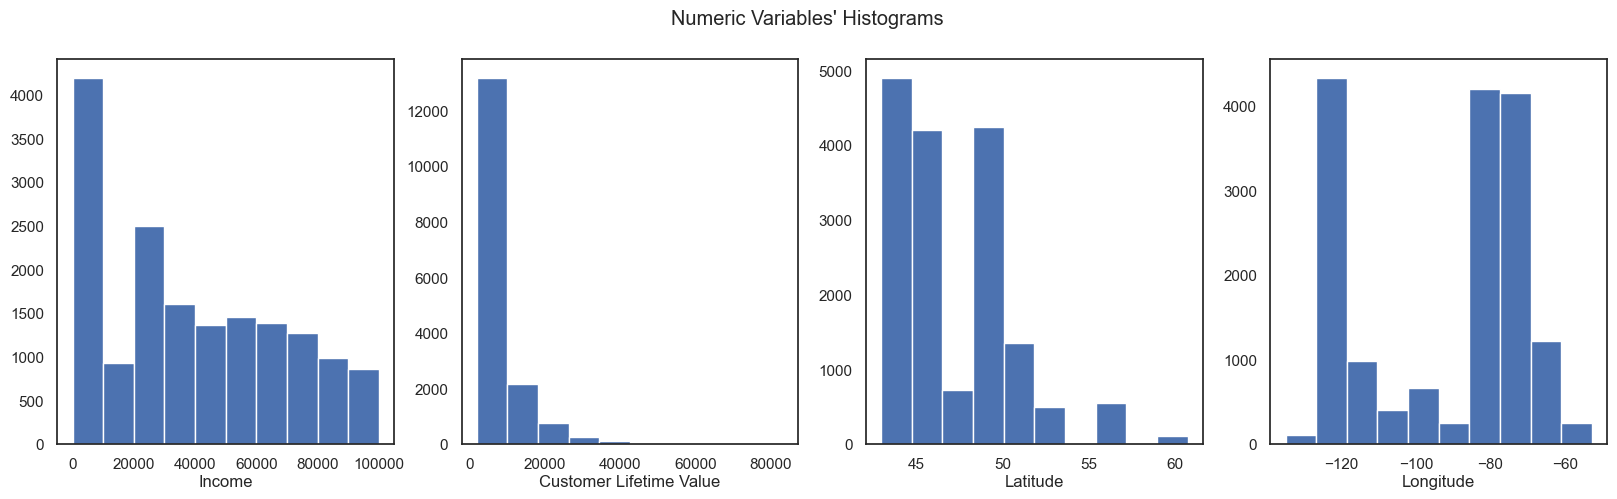

In [40]:
numeric_features_c = [
    'Income',
    'Customer Lifetime Value',
    'Latitude',
    'Longitude',
]

sp_rows = 1
sp_cols = 4

# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 5))

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features_c): 
    ax.hist(df_AIAI_Customers[feat])
    ax.set_title(feat, y=-0.13)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Histograms"
plt.suptitle(title)

plt.show()

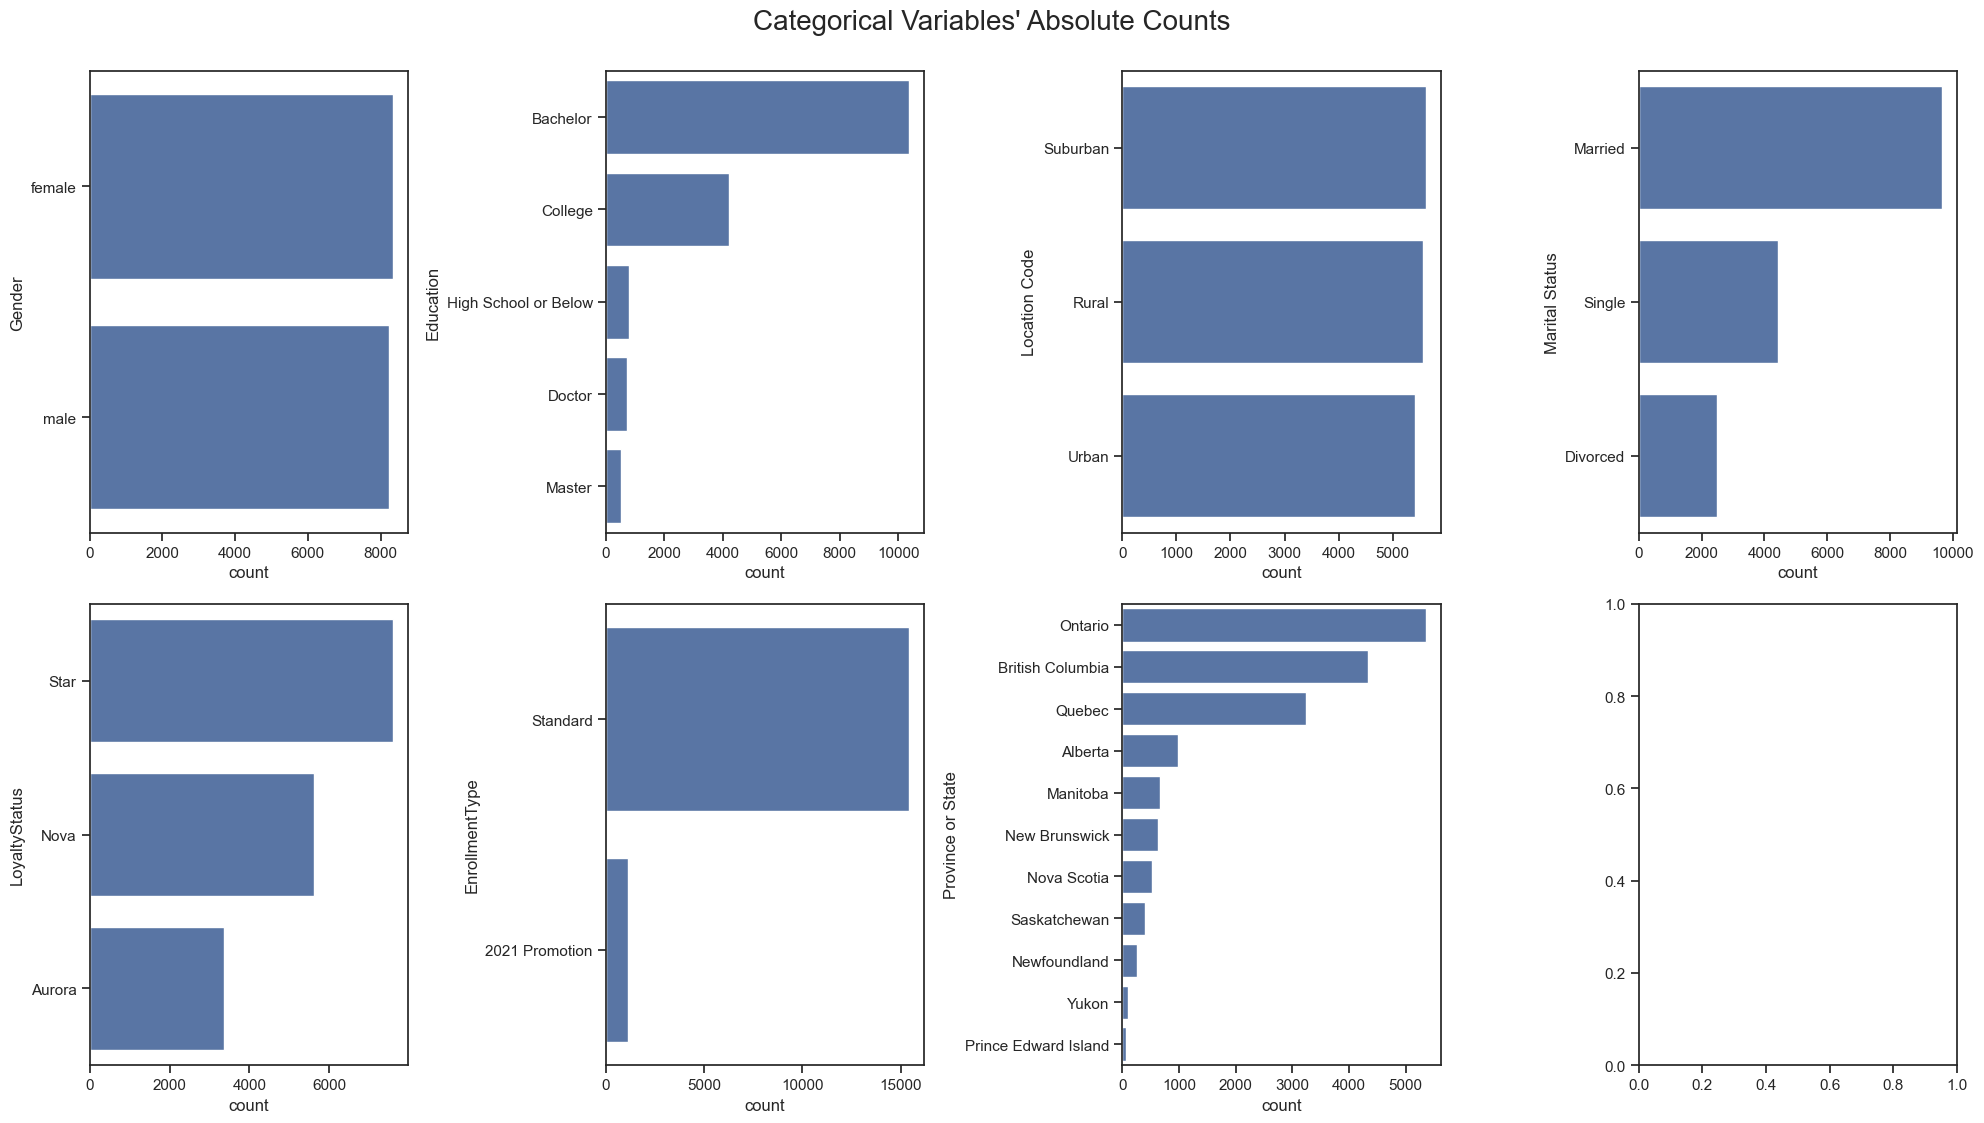

In [41]:
categorical_features_c = [
    'Gender',
    'Education',
    'Location Code',
    'Marital Status',
    'LoyaltyStatus',
    'EnrollmentType',
    'Province or State']

sns.set_context("notebook")
sns.set_style("ticks")
sns.set_style("ticks")
fig, axes = plt.subplots(
    2, 
    ceil(len(categorical_features_c) / 2), 
    figsize=(20, 11)
    )

for ax, feat in zip(axes.flatten(), categorical_features_c):
    # use df_deps
    sns.countplot(y=df_AIAI_Customers[feat], ax=ax, 
                  order=df_AIAI_Customers[feat].value_counts().index) 
    
plt.tight_layout(rect=[0, 0, 1, 0.98])

title="Categorical Variables' Absolute Counts"
plt.suptitle(title, fontsize=20, y=1.02)
plt.show()

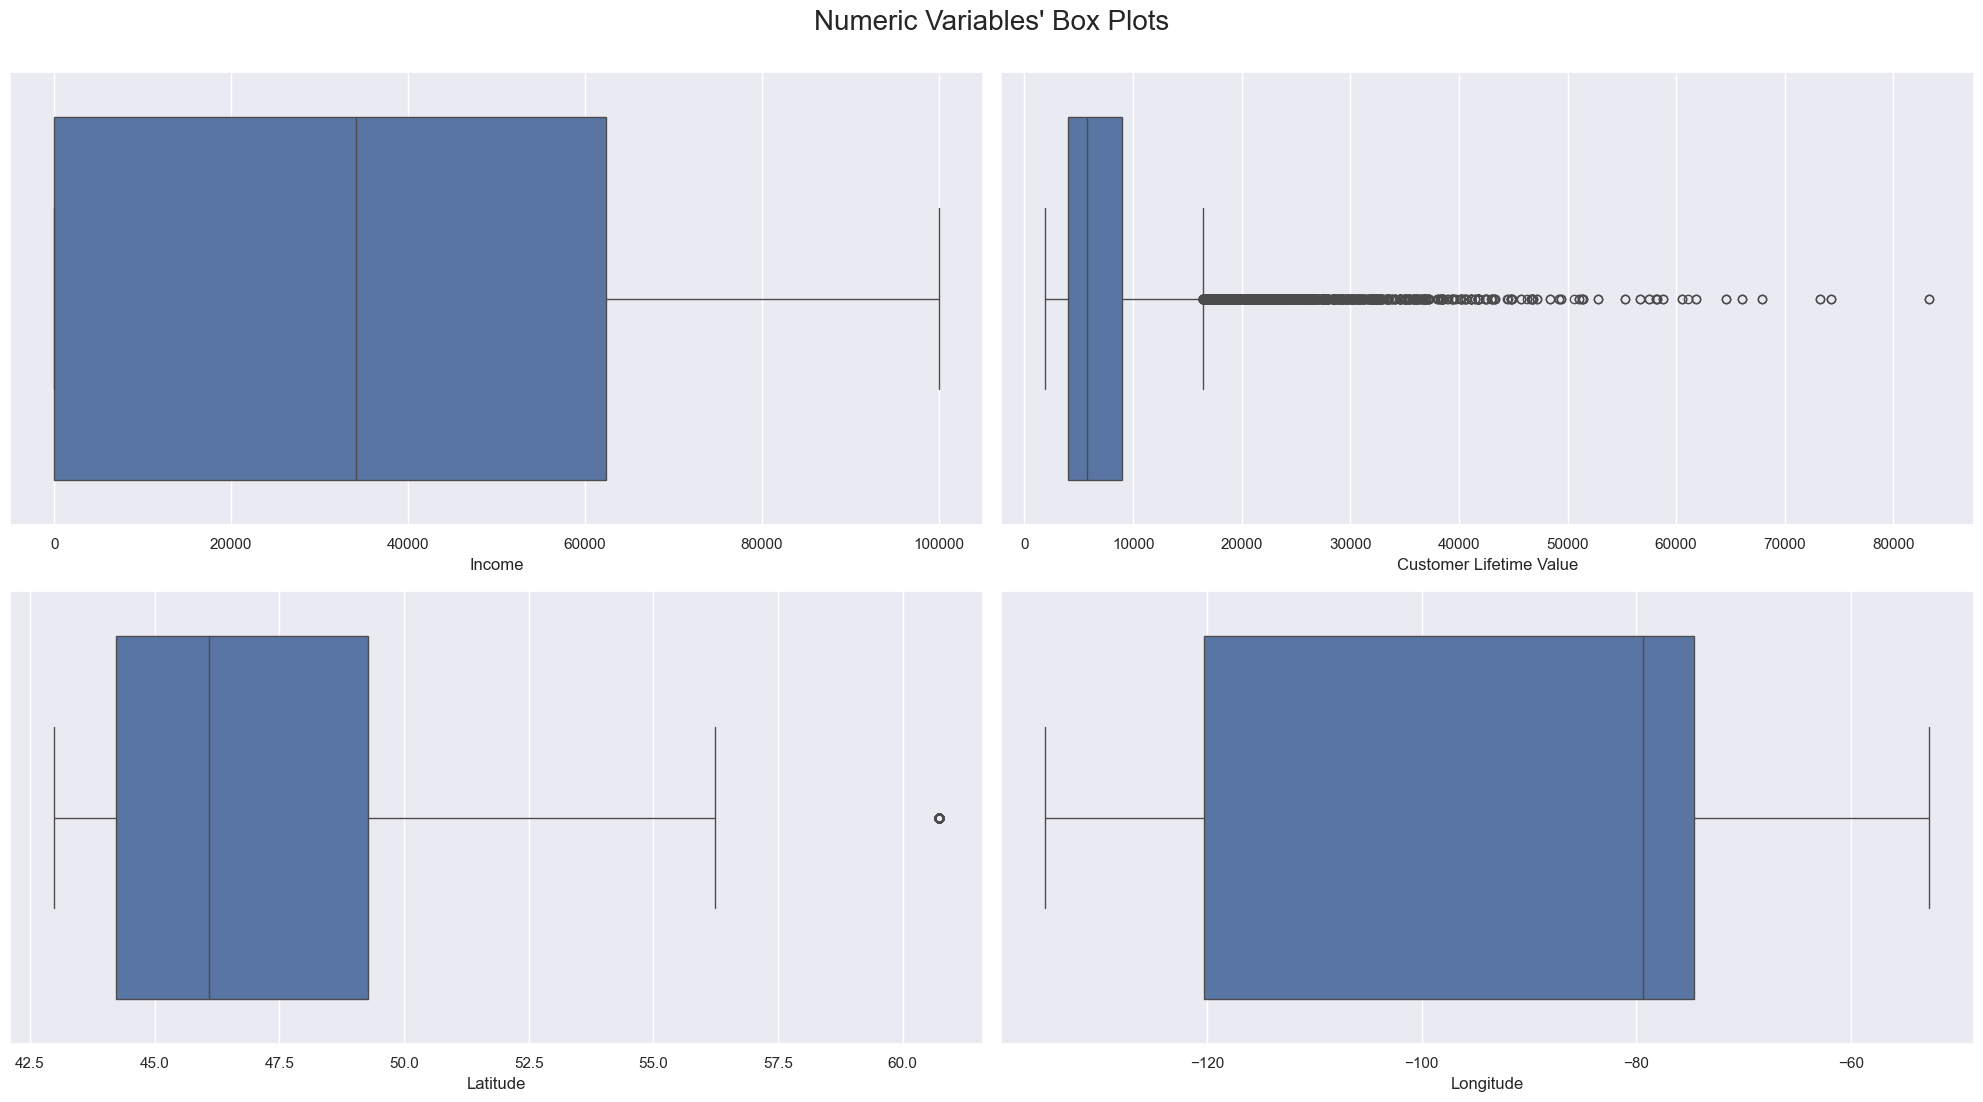

In [42]:
sns.set() ## Reset to darkgrid

sp_rows = 2
sp_cols = ceil(len(numeric_features_c) / sp_rows)


# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11),
                         tight_layout=True
                        )

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features_c): # Notice the zip() function and flatten() method
    sns.boxplot(x=df_AIAI_Customers[feat], ax=ax)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title, fontsize=20, y=1)

plt.show()

#### **Flights DataFrame**

In [43]:
df_AIAI_Flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [44]:
df_AIAI_Flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [45]:
df_AIAI_Flights['Loyalty#'].nunique()

16737

In [46]:
df_AIAI_Flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

We have on total 608436 observations (records of flights), with 0 missing values, and more than 1 value per customer.

The data types are correct on almost every column, meaning that the values stores at least are of the data types that they are supouse to be.

It is only needed to change the data types of the date column YearMonthDate, and transform the colunm NumFlights and NumFlightsWithCompanions to integers, since they should be discrete.

**Duplicates**

In [47]:
df_AIAI_Flights.duplicated(keep=False).sum()
# We have 5778 duplicate rows

np.int64(5778)

We will only keep 1 record per each duplicate since it has the same information.

In [48]:
df_AIAI_Flights = df_AIAI_Flights.drop_duplicates(keep='first')

In [49]:
df_AIAI_Flights.duplicated(subset= ['Loyalty#', 'YearMonthDate'], keep=False).sum()

np.int64(5996)

We also saw that there are some times different records with multiple observations, we will group them and sum the values to have only 1 row per customer per month.

In [50]:
group_cols = ['Loyalty#', 'Year', 'Month', 'YearMonthDate']
agg_dict = {
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'DollarCostPointsRedeemed': 'sum'
}

# Group by the specified columns and aggregate the rest by summing
df_AIAI_Flights = df_AIAI_Flights.groupby(group_cols).agg(agg_dict).reset_index()

In [51]:
df_AIAI_Flights

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,100018,2019,1,1/1/2019,2.7,0.0,11070.0,1107.00,0.0,0.0
1,100018,2019,2,2/1/2019,1.8,1.8,8923.5,892.35,0.0,0.0
2,100018,2019,3,3/1/2019,12.6,2.7,12335.4,1233.54,3121.2,30.6
3,100018,2019,4,4/1/2019,3.6,0.0,5618.7,561.87,0.0,0.0
4,100018,2019,5,5/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
602527,999986,2021,8,8/1/2021,8.0,1.0,28706.0,2870.00,5462.0,54.0
602528,999986,2021,9,9/1/2021,0.0,0.0,0.0,0.00,0.0,0.0
602529,999986,2021,10,10/1/2021,6.0,0.0,3126.0,312.00,0.0,0.0
602530,999986,2021,11,11/1/2021,11.0,4.0,10323.0,1032.00,0.0,0.0


In [52]:
df_AIAI_Flights.duplicated(subset= ['Loyalty#', 'YearMonthDate'], keep=False).sum()

np.int64(0)

**Inconsistencies**

We will check for records that do not have any information (0 flights, 0 distance, 0 points...), to have only information of actual travels.

In [53]:
(df_AIAI_Flights['NumFlights'] == 0).sum()
# Almost half of the records have 0 flights

np.int64(300227)

In [54]:
((df_AIAI_Flights['NumFlights'] == 0) & (df_AIAI_Flights['DistanceKM'] == 0)).sum()

np.int64(294369)

In [55]:
(df_AIAI_Flights['DistanceKM'] == 0).sum()
# When NumFlights is 0, DistanceKM is also 0

np.int64(294369)

Since there are 301621 flights with 0 flights registered we will remove those zero values (a row was created but doesnt have a meaningfull information).

There were records (arround 5000, or aproximatly 2% of the 301621 observations with values) that had values for the distanceKM, but since we do not have information about the airports or routes we will simply remove them since whatever estimation that we will used will not be accurated.

In [56]:
# Remove inconsistency about 0 flights
df_AIAI_Flights = df_AIAI_Flights[~(df_AIAI_Flights['NumFlights'] == 0)]

Now lets fix the datatypes to the correct format.

In [57]:
# Round and convert float columns to integer
df_AIAI_Flights['NumFlights'] = df_AIAI_Flights['NumFlights'].round().astype(int)
df_AIAI_Flights['DistanceKM'] = df_AIAI_Flights['DistanceKM'].round().astype(int)
df_AIAI_Flights['NumFlightsWithCompanions'] = df_AIAI_Flights['NumFlightsWithCompanions'].round().astype(int)

# Converting into Datetime
df_AIAI_Flights['YearMonthDate'] = pd.to_datetime(df_AIAI_Flights['YearMonthDate'], format='%m/%d/%Y')

C:\Users\verov\AppData\Local\Temp\ipykernel_13352\3881134817.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_AIAI_Flights['NumFlights'] = df_AIAI_Flights['NumFlights'].round().astype(int)
C:\Users\verov\AppData\Local\Temp\ipykernel_13352\3881134817.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_AIAI_Flights['DistanceKM'] = df_AIAI_Flights['DistanceKM'].round().astype(int)
C:\Users\verov\AppData\Local\Temp\ipykernel_13352\3881134817.py:4: SettingWithCopyWarning: 
A value is trying to be set on

In [58]:
df_AIAI_Flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302305 entries, 0 to 602530
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  302305 non-null  int64         
 1   Year                      302305 non-null  int64         
 2   Month                     302305 non-null  int64         
 3   YearMonthDate             302305 non-null  datetime64[ns]
 4   NumFlights                302305 non-null  int64         
 5   NumFlightsWithCompanions  302305 non-null  int64         
 6   DistanceKM                302305 non-null  int64         
 7   PointsAccumulated         302305 non-null  float64       
 8   PointsRedeemed            302305 non-null  float64       
 9   DollarCostPointsRedeemed  302305 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(6)
memory usage: 25.4 MB


There are only 302305 entries with actual information about flight history.

In [59]:
(df_AIAI_Flights['NumFlightsWithCompanions'] > df_AIAI_Flights['NumFlights']).sum()
# There are no cases where NumFlightsWithCompanions is greater than NumFlights

np.int64(0)

In [60]:
(round(df_AIAI_Flights['DistanceKM'] / 10) == df_AIAI_Flights['PointsAccumulated']).sum()
# The PointsAccumulated is aproximatly the DistanceKM divided by 10

np.int64(114451)

In [61]:
((df_AIAI_Flights['DistanceKM'] > 0) & (df_AIAI_Flights['PointsAccumulated'] == 0)).sum()
# No inconsistencies found where there are DistanceKM but no PointsAccumulated

np.int64(0)

In [62]:
(round(df_AIAI_Flights['PointsRedeemed'] / 100) == df_AIAI_Flights['DollarCostPointsRedeemed']).sum()
# The DollarCostPointsRedeemed is aproximatly PointsRedeemed divided by 100

np.int64(279928)

In [63]:
((df_AIAI_Flights['PointsRedeemed'] > 0) & (df_AIAI_Flights['DollarCostPointsRedeemed'] == 0)).sum()
# No inconsistencies found where there are PointsRedeemed but no DollarCostPointsRedeemed

np.int64(0)

In [64]:
df_AIAI_Flights['Loyalty#'].nunique()

15236

In [65]:
df_AIAI_Flights.describe()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,302305.000000,302305.000000,302305.000000,302305,302305.000000,302305.000000,302305.000000,302305.000000,302305.000000,302305.000000
mean,548896.064716,2020.049364,6.643536,2020-07-08 12:25:38.340417536,7.869714,1.984827,15673.570004,1567.048160,473.480723,4.679093
min,100018.000000,2019.000000,1.000000,2019-01-01 00:00:00,1.000000,0.000000,238.000000,23.850000,0.000000,0.000000
25%,326699.000000,2019.000000,4.000000,2019-10-01 00:00:00,4.000000,0.000000,7828.000000,782.550000,0.000000,0.000000
50%,549537.000000,2020.000000,7.000000,2020-08-01 00:00:00,7.000000,1.000000,15114.000000,1511.000000,0.000000,0.000000
75%,771307.000000,2021.000000,10.000000,2021-04-01 00:00:00,11.000000,4.000000,22641.000000,2264.000000,0.000000,0.000000
max,999986.000000,2021.000000,12.000000,2021-12-01 00:00:00,39.000000,20.000000,78327.000000,7831.000000,8036.000000,80.000000
std,258219.624521,0.825037,3.449432,NaN,4.587752,2.462363,9458.282280,945.810094,1354.282810,13.395916


Conclusions:
+ We have information from year 2019 to 2021 (3 years).
+ We have information from every month.
+ We see that we can use the DistanceKM to estimate the PointsAccumulated (PointsAccumulated = DistanceKM/10).
+ We see that we can use the PointsAccumulated to estimate the DollarCostPoints (DollarCostPoints = PointsAccumulated / 100).
+ We have information about 15236 unique customers, we will se which ones they are joining this dataset to the customer dataset, the missing Ids will have misisng values on those new joined columns and they only will have custers related to demografic atributes, being the same cluster for the rest of groups (Value-based segmentation, and Behavioral segmentation).
+ We see that on the DistanceKM variable the maximum is 78000 km, something that is not possible, for that reason for our analysis we will used the median value or use a treshold.

**Initial Visualizations**

In [261]:
# histograms, boxplots.

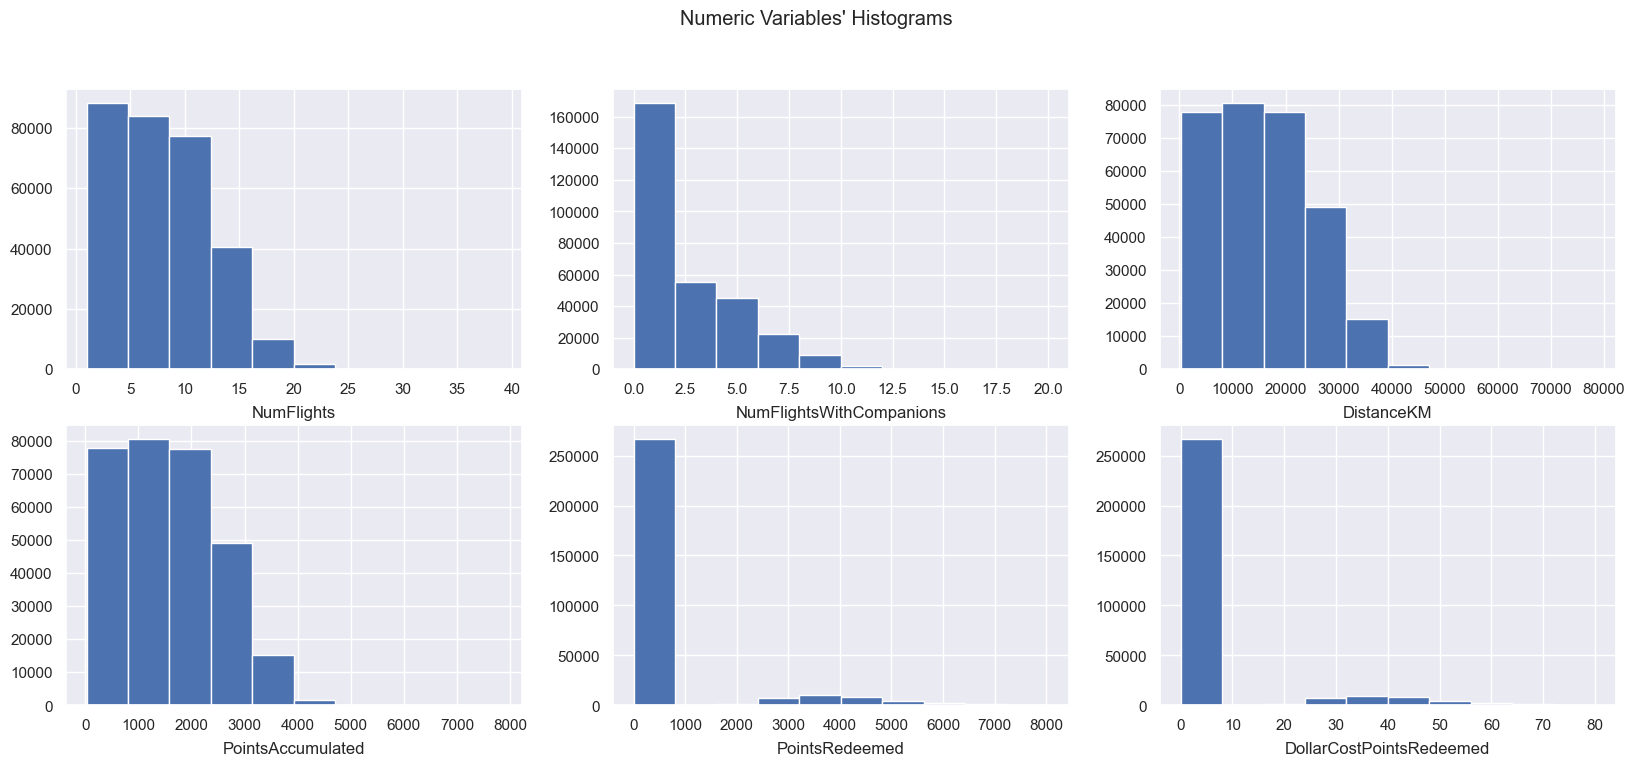

In [66]:
numeric_features_f = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'DollarCostPointsRedeemed'
]

sp_rows = 2
sp_cols = 3

# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 8))

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features_f): 
    ax.hist(df_AIAI_Flights[feat])
    ax.set_title(feat, y=-0.2)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Histograms"
plt.suptitle(title)

plt.show()

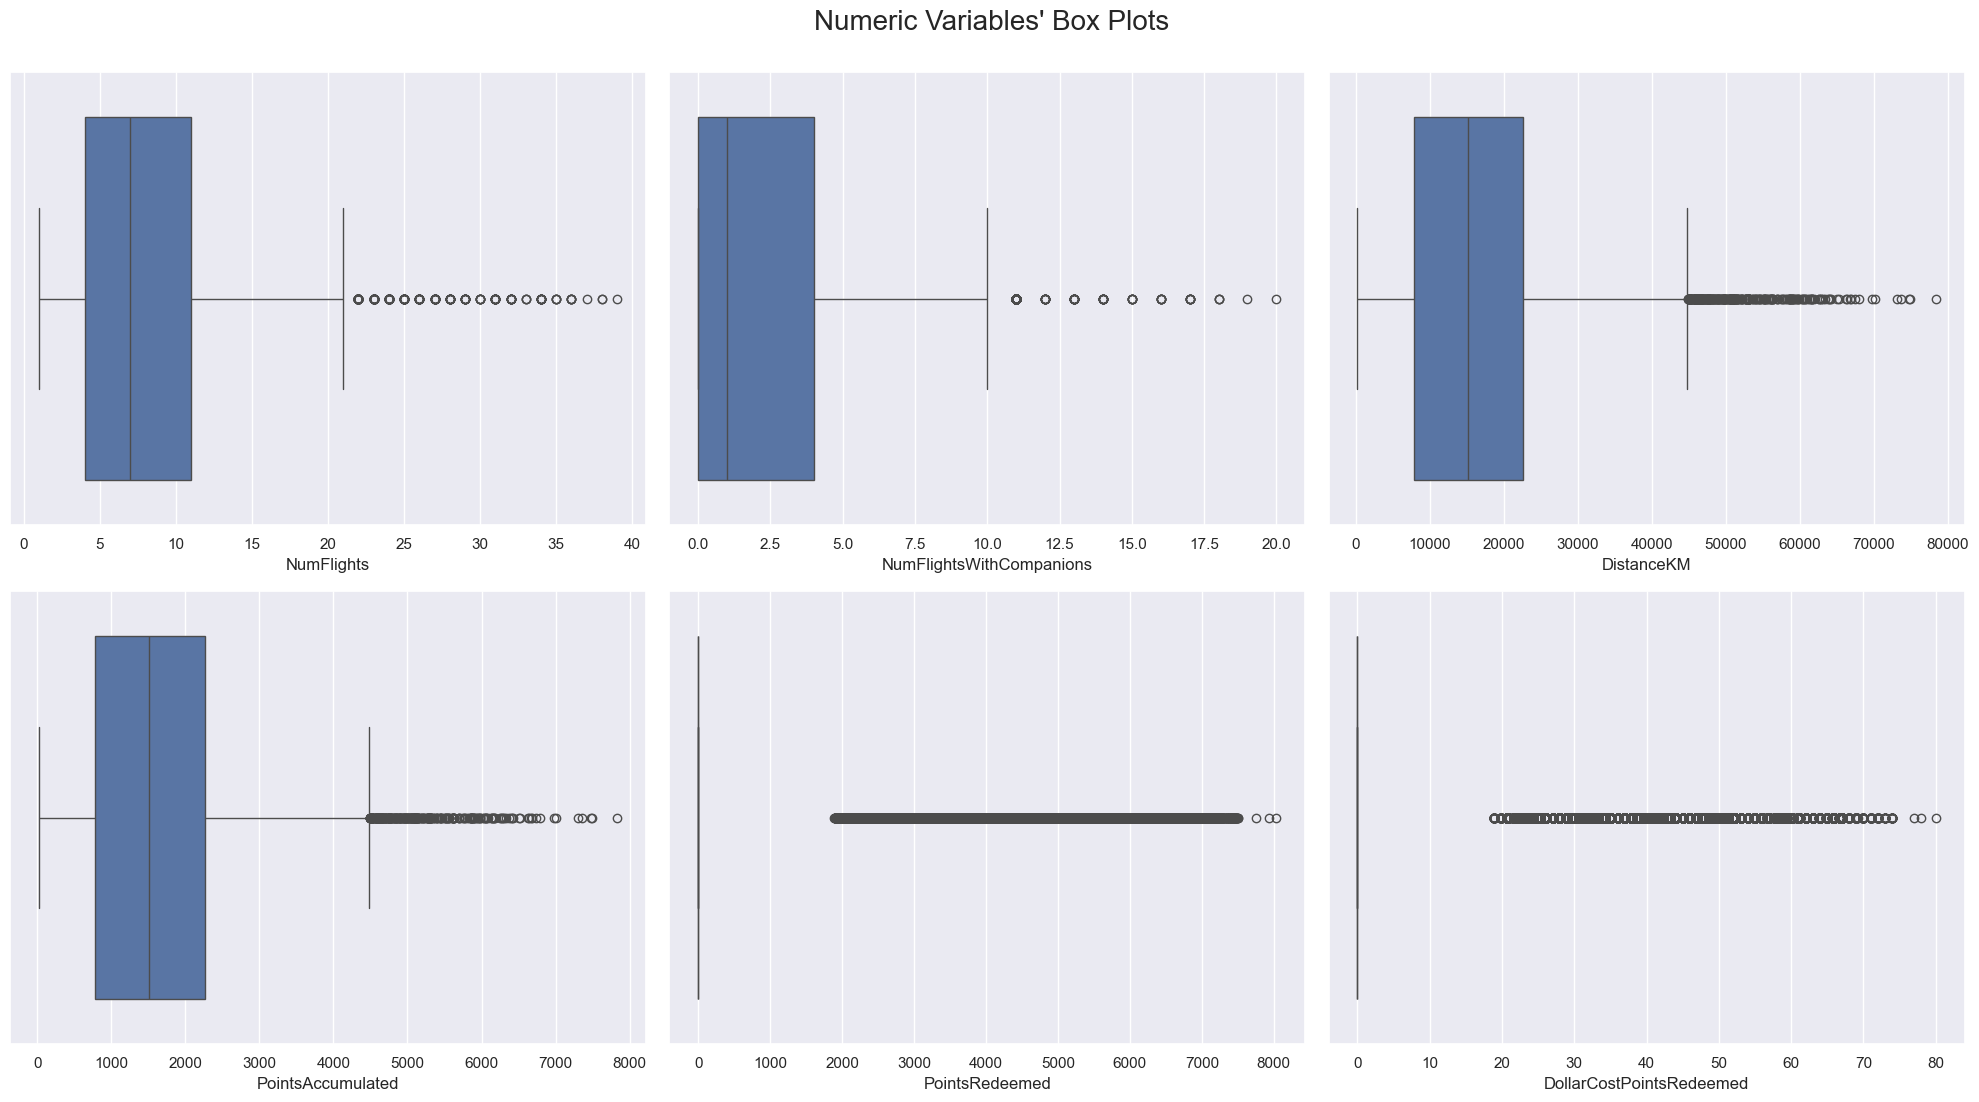

In [67]:
sns.set() ## Reset to darkgrid

sp_rows = 2
sp_cols = ceil(len(numeric_features_f) / sp_rows)


# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11),
                         tight_layout=True
                        )

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features_f): # Notice the zip() function and flatten() method
    sns.boxplot(x=df_AIAI_Flights[feat], ax=ax)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title, fontsize=20, y=1)

plt.show()

**Joining the Datasets**

In [68]:
df_AIAI_Customers.index.isin(df_AIAI_Flights['Loyalty#'].unique()).sum()

np.int64(15101)

In [69]:
(~df_AIAI_Customers.index.isin(df_AIAI_Flights['Loyalty#'].unique())).sum()

np.int64(1471)

Only 15101 customers had a correspondance to the flight data, the rest (1471 customers) do not have travel data.

In [70]:
df_AIAI_Flights['Loyalty#'].isin(df_AIAI_Customers.index).sum()

np.int64(299345)

In [71]:
(~df_AIAI_Flights['Loyalty#'].isin(df_AIAI_Customers.index)).sum()

np.int64(2960)

We have a correspondance on 299345 records, only 2960 records do not have a customer associated, so these rows will not be used since they cannot be merged with a customer.

Since we do not have a 1:1 correspondance between table, to join these datasets we will need to perform some agregations on the flight dataset to have only 1 value per customer. More specifically we will create the following variables using the flight data:

- *Total_NumFlights:* - Total number of flights.
- *Total_DistanceKM:* - Total distance of flights on KM.
- *Total_NumFlights_With_Companions:* - Total number of flights with companions.
- *Perc_Flights_With_Companions:* - Percentage of flights with companions.
- *Total_Points_Accumulated:* - Total points accumulated over the entire period.
- *Total_Points_Redeemed:* - Total points redeemed over the entire period.
- *Dollar_Cost_Points_Remaining:* - Dollar value of points available for redemption.

**Year Agregation**
- *Total_NumFlights_Per_Year:* - Total number of flights per year (one colum per year).
- *Total_DistanceKM_Per_Year:* - Total distance traveled per year on KM (one colum per year).
- *Total_NumFlights_With_Companions_Per_Year:* - Total number of flights with companions per year (one colum per year).
- *Perc_Flights_With_Companions_Per_Year:* - Percentage of flights with companions per year (one colum per year).
- *Total_Points_Accumulated_Per_Year:* - Total points accumulated per year (one colum per year).
- *Dollar_Cost_Points_Remaining_Per_Year:* - Dollar value of points remaining per year (one colum per year).
- *Median_Flights_Per_Year:* - Median number of flights per year.
- *Median_Distance_Per_Year:* - Median distance traveled per year on KM.
- *Median_Points_Accumulated_Per_Year:* - Median points accumulated per year.
- *Median_Points_Redeemed_Per_Year:* - Median points redeemed per year.
- *Median_Dollar_Cost_Points_Remaining_Per_Year:* - Median dollar cost of points redeemed per year.
- *Year_With_Max_Distance:* - Year with the maximum distance traveled.
- *Most_Frequent_Flight_Year:* - Year with the highest number of flights.

**Month-Year Aggregation (VER SI DEJO O NO)**
- *Total_NumFlights_Per_Month_Per_Year:* - Total number of flights per month for each year (e.g., Total_NumFlights_2019_1).
- *Total_DistanceKM_Per_Month_Per_Year:* - Total distance traveled per month for each year on KM.
- *Total_NumFlights_With_Companions_Per_Month_Per_Year:* - Total number of flights with companions per month for each year.
- *Perc_Flights_With_Companions_Per_Month_Per_Year:* - Percentage of flights with companions per month for each year.
- *Total_Points_Accumulated_Per_Month_Per_Year:* - Total points accumulated per month for each year.
- *Dollar_Cost_Points_Remaining_Per_Month_Per_Year:* - Dollar value of points remaining per month for each year.
- *Median_Flights_Per_Month:* - Median number of flights across all active months for a customer.
- *Median_Distance_Per_Month:* - Median distance traveled across all active months for a customer.
- *Median_Points_Accumulated_Per_Month:* - Median points accumulated across all active months for a customer.
- *Median_Points_Redeemed_Per_Month:* - Median points redeemed across all active months for a customer.
- *Median_Dollar_Cost_Points_Remaining_Per_Month:* - Median dollar cost of points remaining across all active months for a customer.
- *Month_Year_With_Max_Distance:* - The specific month and year with the maximum distance traveled.
- *Most_Frequent_Flight_Month_Year:* - The specific month and year with the highest number of flights.
- *Month_With_Max_Distance:* - Month with the maximum distance traveled.
- *Most_Frequent_Flight_Month:* - Month with the highest number of flights.


In [72]:
# First, filter out flights that don't have a corresponding customer
df_AIAI_Flights_cleaned = df_AIAI_Flights[df_AIAI_Flights['Loyalty#'].isin(df_AIAI_Customers.index)].copy()

In [73]:
# --- Total Aggregations per Customer ---

# Define aggregations for total calculations
agg_dict_total = {
    'NumFlights': 'sum',
    'DistanceKM': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum'
}

# Group by Loyalty# and aggregate to get total values
df_flights_agg = df_AIAI_Flights_cleaned.groupby('Loyalty#').agg(agg_dict_total)

# Rename columns for clarity
df_flights_agg.rename(columns={
    'NumFlights': 'Total_NumFlights',
    'DistanceKM': 'Total_DistanceKM',
    'NumFlightsWithCompanions': 'Total_NumFlights_With_Companions',
    'PointsAccumulated': 'Total_Points_Accumulated',
    'PointsRedeemed': 'Total_Points_Redeemed'
}, inplace=True)

# --- Calculate Derived Metrics ---

# Calculate the percentage of flights with companions
# Use fillna(0) to handle cases where a customer has 0 flights
df_flights_agg['Perc_Flights_With_Companions'] = (
    (df_flights_agg['Total_NumFlights_With_Companions'] / df_flights_agg['Total_NumFlights']).fillna(0) * 100
)

# Calculate the dollar value of the remaining points
df_flights_agg['Dollar_Cost_Points_Remaining'] = (
    df_flights_agg['Total_Points_Accumulated'] - df_flights_agg['Total_Points_Redeemed']
) / 100

# Display the first few rows of the resulting dataframe
df_flights_agg.head()

,Total_NumFlights,Total_DistanceKM,Total_NumFlights_With_Companions,Total_Points_Accumulated,Total_Points_Redeemed,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining
Loyalty#,,,,,,,
100018,231,530230,50,53014.30,20562.8,21.645022,324.5150
100102,248,339115,59,33903.96,18760.6,23.790323,151.4336
100140,217,432030,54,43192.58,4896.0,24.884793,382.9658
100214,112,364601,20,36453.77,12908.6,17.857143,235.4517
100272,187,429631,53,42953.25,10891.4,28.342246,320.6185


In [74]:
# --- Yearly Aggregations ---

# Group by customer and year to get yearly totals
df_yearly_agg = df_AIAI_Flights_cleaned.groupby(['Loyalty#', 'Year']).agg(
    NumFlights_sum=('NumFlights', 'sum'),
    DistanceKM_sum=('DistanceKM', 'sum'),
    NumFlightsWithCompanions_sum=('NumFlightsWithCompanions', 'sum'),
    PointsAccumulated_sum=('PointsAccumulated', 'sum'),
    PointsRedeemed_sum=('PointsRedeemed', 'sum')
).reset_index()

# --- Pivoted Features (one column per year) ---

# Pivot for NumFlights
df_yearly_pivot_flights = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='NumFlights_sum', fill_value=0)
df_yearly_pivot_flights.columns = [f'Total_NumFlights_{year}' for year in df_yearly_pivot_flights.columns]

# Pivot for DistanceKM
df_yearly_pivot_distance = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='DistanceKM_sum', fill_value=0)
df_yearly_pivot_distance.columns = [f'Total_DistanceKM_{year}' for year in df_yearly_pivot_distance.columns]

# Pivot for NumFlightsWithCompanions
df_yearly_pivot_companions = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='NumFlightsWithCompanions_sum', fill_value=0)
df_yearly_pivot_companions.columns = [f'Total_NumFlights_With_Companions_{year}' for year in df_yearly_pivot_companions.columns]

# Pivot for PointsAccumulated
df_yearly_pivot_points_acc = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='PointsAccumulated_sum', fill_value=0)
df_yearly_pivot_points_acc.columns = [f'Total_Points_Accumulated_{year}' for year in df_yearly_pivot_points_acc.columns]

# Pivot for PointsRedeemed
df_yearly_pivot_points_red = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='PointsRedeemed_sum', fill_value=0)
df_yearly_pivot_points_red.columns = [f'Total_Points_Redeemed_{year}' for year in df_yearly_pivot_points_red.columns]


# --- Median and Behavioral Flag Features ---

# Calculate Dollar Cost Points Remaining per year in the intermediate dataframe
df_yearly_agg['Dollar_Cost_Points_Remaining'] = (df_yearly_agg['PointsAccumulated_sum'] - df_yearly_agg['PointsRedeemed_sum']) / 100

# Now, aggregate the yearly stats to get median values and behavioral flags
df_customer_yearly_summary = df_yearly_agg.groupby('Loyalty#').agg(
    Median_Flights_Per_Year=('NumFlights_sum', 'median'),
    Median_Distance_Per_Year=('DistanceKM_sum', 'median'),
    Median_Points_Accumulated_Per_Year=('PointsAccumulated_sum', 'median'),
    Median_Points_Redeemed_Per_Year=('PointsRedeemed_sum', 'median'),
    Median_Dollar_Cost_Points_Remaining_Per_Year=('Dollar_Cost_Points_Remaining', 'median')
)

# Find the year with the maximum distance and most flights for each customer
df_customer_yearly_summary['Year_With_Max_Distance'] = df_yearly_agg.loc[df_yearly_agg.groupby('Loyalty#')['DistanceKM_sum'].idxmax()]['Year'].values
df_customer_yearly_summary['Most_Frequent_Flight_Year'] = df_yearly_agg.loc[df_yearly_agg.groupby('Loyalty#')['NumFlights_sum'].idxmax()]['Year'].values


# --- Combine all yearly features ---

# Merge all pivoted tables and summary table
df_yearly_features = pd.concat([
    df_yearly_pivot_flights,
    df_yearly_pivot_distance,
    df_yearly_pivot_companions,
    df_yearly_pivot_points_acc,
    df_yearly_pivot_points_red,
    df_customer_yearly_summary
], axis=1)

# Calculate percentage and dollar cost columns for the pivoted data
for year in df_AIAI_Flights_cleaned['Year'].unique():
    # Percentage of flights with companions per year
    num_flights_col = f'Total_NumFlights_{year}'
    companions_col = f'Total_NumFlights_With_Companions_{year}'
    perc_companions_col = f'Perc_Flights_With_Companions_{year}'
    
    if num_flights_col in df_yearly_features.columns and companions_col in df_yearly_features.columns:
        df_yearly_features[perc_companions_col] = (df_yearly_features[companions_col] / df_yearly_features[num_flights_col]).fillna(0) * 100

    # Dollar cost of points remaining per year
    points_acc_col = f'Total_Points_Accumulated_{year}'
    points_red_col = f'Total_Points_Redeemed_{year}'
    dollar_cost_col = f'Dollar_Cost_Points_Remaining_{year}'

    if points_acc_col in df_yearly_features.columns and points_red_col in df_yearly_features.columns:
        df_yearly_features[dollar_cost_col] = (df_yearly_features[points_acc_col] - df_yearly_features[points_red_col]) / 100


In [75]:
# --- Sort Columns for Readability ---

# Get the unique years and sort them
years = sorted(df_AIAI_Flights_cleaned['Year'].unique())

# Define the base order of metrics
metric_order = [
    'Total_NumFlights',
    'Total_DistanceKM',
    'Total_NumFlights_With_Companions',
    'Perc_Flights_With_Companions',
    'Total_Points_Accumulated',
    'Total_Points_Redeemed',
    'Dollar_Cost_Points_Remaining'
]

# Create the list of sorted columns by metric, then by year
sorted_metric_cols = [f'{metric}_{year}' for metric in metric_order for year in years if f'{metric}_{year}' in df_yearly_features.columns]

# Get the remaining general summary columns
general_cols = [col for col in df_yearly_features.columns if col not in sorted_metric_cols]

# Combine the lists to get the final column order
final_col_order = sorted_metric_cols + general_cols

# Reorder the DataFrame
df_yearly_features = df_yearly_features[final_col_order]

# Display the transposed head to verify the new order
df_yearly_features.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Total_NumFlights_With_Companions_2019,Total_NumFlights_With_Companions_2020,Total_NumFlights_With_Companions_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Total_Points_Accumulated_2019,Total_Points_Accumulated_2020,Total_Points_Accumulated_2021,Total_Points_Redeemed_2019,Total_Points_Redeemed_2020,Total_Points_Redeemed_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Median_Flights_Per_Year,Median_Distance_Per_Year,Median_Points_Accumulated_Per_Year,Median_Points_Redeemed_Per_Year,Median_Dollar_Cost_Points_Remaining_Per_Year,Year_With_Max_Distance,Most_Frequent_Flight_Year
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100018,74.0,81.0,76.0,171693.0,190770.0,167767.0,15.0,16.0,19.0,20.270270,19.753086,25.000000,17169.30,19072.0,16773.0,8326.8,9252.0,2984.0,88.4250,98.20,137.89,76.0,171693.0,17169.30,8326.8,98.2000,2020,2020
100102,75.0,83.0,90.0,89410.0,99344.0,150361.0,17.0,18.0,24.0,22.666667,21.686747,26.666667,8940.96,9931.0,15032.0,8886.6,9874.0,0.0,0.5436,0.57,150.32,83.0,99344.0,9931.00,8886.6,0.5700,2021,2021
100140,65.0,72.0,80.0,158995.0,176662.0,96373.0,16.0,18.0,20.0,24.615385,25.000000,25.000000,15899.58,17661.0,9632.0,0.0,0.0,4896.0,158.9958,176.61,47.36,72.0,158995.0,15899.58,0.0,158.9958,2020,2021
100214,33.0,37.0,42.0,106067.0,117853.0,140681.0,3.0,3.0,14.0,9.090909,8.108108,33.333333,10606.77,11782.0,14065.0,6114.6,6794.0,0.0,44.9217,49.88,140.65,37.0,117853.0,11782.00,6114.6,49.8800,2021,2021
100272,60.0,66.0,61.0,145103.0,161225.0,123303.0,17.0,19.0,17.0,28.333333,28.787879,27.868852,14510.25,16118.0,12325.0,2750.4,3056.0,5085.0,117.5985,130.62,72.40,61.0,145103.0,14510.25,3056.0,117.5985,2020,2020


In [76]:
# --- Monthly Aggregations per Year ---

# The df_AIAI_Flights_cleaned is already aggregated at the Loyalty#, Year, and Month level.
# We will use this as our base for monthly-yearly features.
df_monthly_yearly_agg = df_AIAI_Flights_cleaned.copy()

# Create a 'Year_Month' column for easier pivoting
df_monthly_yearly_agg['Year_Month'] = df_monthly_yearly_agg['Year'].astype(str) + '_' + df_monthly_yearly_agg['Month'].astype(str)

# --- Pivoted Features (one column per Year-Month) ---

# Pivot for NumFlights
df_pivot_flights = df_monthly_yearly_agg.pivot_table(index='Loyalty#', columns='Year_Month', values='NumFlights', fill_value=0)
df_pivot_flights.columns = [f'Total_NumFlights_{col}' for col in df_pivot_flights.columns]

# Pivot for DistanceKM
df_pivot_distance = df_monthly_yearly_agg.pivot_table(index='Loyalty#', columns='Year_Month', values='DistanceKM', fill_value=0)
df_pivot_distance.columns = [f'Total_DistanceKM_{col}' for col in df_pivot_distance.columns]

# Pivot for NumFlightsWithCompanions
df_pivot_companions = df_monthly_yearly_agg.pivot_table(index='Loyalty#', columns='Year_Month', values='NumFlightsWithCompanions', fill_value=0)
df_pivot_companions.columns = [f'Total_NumFlights_With_Companions_{col}' for col in df_pivot_companions.columns]

# Pivot for PointsAccumulated
df_pivot_points_acc = df_monthly_yearly_agg.pivot_table(index='Loyalty#', columns='Year_Month', values='PointsAccumulated', fill_value=0)
df_pivot_points_acc.columns = [f'Total_Points_Accumulated_{col}' for col in df_pivot_points_acc.columns]

# Pivot for PointsRedeemed
df_pivot_points_red = df_monthly_yearly_agg.pivot_table(index='Loyalty#', columns='Year_Month', values='PointsRedeemed', fill_value=0)
df_pivot_points_red.columns = [f'Total_Points_Redeemed_{col}' for col in df_pivot_points_red.columns]


# --- Median and Behavioral Flag Features ---

# Calculate Dollar Cost Points Remaining for each month-year record
df_monthly_yearly_agg['Dollar_Cost_Points_Remaining'] = (df_monthly_yearly_agg['PointsAccumulated'] - df_monthly_yearly_agg['PointsRedeemed']) / 100

# Aggregate the monthly-yearly stats to get median values and behavioral flags for each customer
df_customer_monthly_summary = df_monthly_yearly_agg.groupby('Loyalty#').agg(
    Median_Flights_Per_Month=('NumFlights', 'median'),
    Median_Distance_Per_Month=('DistanceKM', 'median'),
    Median_Points_Accumulated_Per_Month=('PointsAccumulated', 'median'),
    Median_Points_Redeemed_Per_Month=('PointsRedeemed', 'median'),
    Median_Dollar_Cost_Points_Remaining_Per_Month=('Dollar_Cost_Points_Remaining', 'median')
)

# Find the month-year with the maximum distance and most flights for each customer
df_customer_monthly_summary['Month_Year_With_Max_Distance'] = df_monthly_yearly_agg.loc[df_monthly_yearly_agg.groupby('Loyalty#')['DistanceKM'].idxmax()]['Year_Month'].values
df_customer_monthly_summary['Most_Frequent_Flight_Month_Year'] = df_monthly_yearly_agg.loc[df_monthly_yearly_agg.groupby('Loyalty#')['NumFlights'].idxmax()]['Year_Month'].values


# --- Combine all monthly-yearly features ---

# Merge all pivoted tables and summary table
df_monthly_yearly_features = pd.concat([
    df_pivot_flights,
    df_pivot_distance,
    df_pivot_companions,
    df_pivot_points_acc,
    df_pivot_points_red,
    df_customer_monthly_summary
], axis=1)

# Calculate percentage and dollar cost columns for the pivoted data
for year_month in df_monthly_yearly_agg['Year_Month'].unique():
    # Percentage of flights with companions
    num_flights_col = f'Total_NumFlights_{year_month}'
    companions_col = f'Total_NumFlights_With_Companions_{year_month}'
    perc_companions_col = f'Perc_Flights_With_Companions_{year_month}'
    
    if num_flights_col in df_monthly_yearly_features.columns and companions_col in df_monthly_yearly_features.columns:
        df_monthly_yearly_features[perc_companions_col] = (df_monthly_yearly_features[companions_col] / df_monthly_yearly_features[num_flights_col]).fillna(0) * 100

    # Dollar cost of points remaining
    points_acc_col = f'Total_Points_Accumulated_{year_month}'
    points_red_col = f'Total_Points_Redeemed_{year_month}'
    dollar_cost_col = f'Dollar_Cost_Points_Remaining_{year_month}'

    if points_acc_col in df_monthly_yearly_features.columns and points_red_col in df_monthly_yearly_features.columns:
        df_monthly_yearly_features[dollar_cost_col] = (df_monthly_yearly_features[points_acc_col] - df_monthly_yearly_features[points_red_col]) / 100

# --- Sort Columns for Readability ---

# Define the base order of metrics
metric_order = [
    'Total_NumFlights',
    'Total_DistanceKM',
    'Total_NumFlights_With_Companions',
    'Perc_Flights_With_Companions',
    'Total_Points_Accumulated',
    'Total_Points_Redeemed',
    'Dollar_Cost_Points_Remaining'
]

# Get unique years and months and sort them
years = sorted(df_monthly_yearly_agg['Year'].unique())
months = sorted(df_monthly_yearly_agg['Month'].unique())

# Create the list of sorted columns by metric, then by year, then by month
sorted_metric_cols = [
    f'{metric}_{year}_{month}' 
    for metric in metric_order 
    for year in years 
    for month in months 
    if f'{metric}_{year}_{month}' in df_monthly_yearly_features.columns
]

# Get the remaining general summary columns
general_cols = [col for col in df_monthly_yearly_features.columns if col not in sorted_metric_cols]

# Combine the lists to get the final column order
final_col_order = sorted_metric_cols + general_cols

# Reorder the DataFrame
df_monthly_yearly_features = df_monthly_yearly_features[final_col_order]

# Display the transposed head to verify the new order
df_monthly_yearly_features.head()

,Total_NumFlights_2019_1,Total_NumFlights_2019_2,Total_NumFlights_2019_3,Total_NumFlights_2019_4,Total_NumFlights_2019_5,Total_NumFlights_2019_6,Total_NumFlights_2019_7,Total_NumFlights_2019_8,Total_NumFlights_2019_9,Total_NumFlights_2019_10,Total_NumFlights_2019_11,Total_NumFlights_2019_12,Total_NumFlights_2020_1,Total_NumFlights_2020_2,Total_NumFlights_2020_3,Total_NumFlights_2020_4,Total_NumFlights_2020_5,Total_NumFlights_2020_6,Total_NumFlights_2020_7,Total_NumFlights_2020_8,Total_NumFlights_2020_9,Total_NumFlights_2020_10,Total_NumFlights_2020_11,Total_NumFlights_2020_12,Total_NumFlights_2021_1,Total_NumFlights_2021_2,Total_NumFlights_2021_3,Total_NumFlights_2021_4,Total_NumFlights_2021_5,Total_NumFlights_2021_6,Total_NumFlights_2021_7,Total_NumFlights_2021_8,Total_NumFlights_2021_9,Total_NumFlights_2021_10,Total_NumFlights_2021_11,Total_NumFlights_2021_12,Total_DistanceKM_2019_1,Total_DistanceKM_2019_2,Total_DistanceKM_2019_3,Total_DistanceKM_2019_4,Total_DistanceKM_2019_5,Total_DistanceKM_2019_6,Total_DistanceKM_2019_7,Total_DistanceKM_2019_8,Total_DistanceKM_2019_9,Total_DistanceKM_2019_10,Total_DistanceKM_2019_11,Total_DistanceKM_2019_12,Total_DistanceKM_2020_1,Total_DistanceKM_2020_2,Total_DistanceKM_2020_3,Total_DistanceKM_2020_4,Total_DistanceKM_2020_5,Total_DistanceKM_2020_6,Total_DistanceKM_2020_7,Total_DistanceKM_2020_8,Total_DistanceKM_2020_9,Total_DistanceKM_2020_10,Total_DistanceKM_2020_11,Total_DistanceKM_2020_12,Total_DistanceKM_2021_1,Total_DistanceKM_2021_2,Total_DistanceKM_2021_3,Total_DistanceKM_2021_4,Total_DistanceKM_2021_5,Total_DistanceKM_2021_6,Total_DistanceKM_2021_7,Total_DistanceKM_2021_8,Total_DistanceKM_2021_9,Total_DistanceKM_2021_10,Total_DistanceKM_2021_11,Total_DistanceKM_2021_12,Total_NumFlights_With_Companions_2019_1,Total_NumFlights_With_Companions_2019_2,Total_NumFlights_With_Companions_2019_3,Total_NumFlights_With_Companions_2019_4,Total_NumFlights_With_Companions_2019_5,Total_NumFlights_With_Companions_2019_6,Total_NumFlights_With_Companions_2019_7,Total_NumFlights_With_Companions_2019_8,Total_NumFlights_With_Companions_2019_9,Total_NumFlights_With_Companions_2019_10,Total_NumFlights_With_Companions_2019_11,Total_NumFlights_With_Companions_2019_12,Total_NumFlights_With_Companions_2020_1,Total_NumFlights_With_Companions_2020_2,Total_NumFlights_With_Companions_2020_3,Total_NumFlights_With_Companions_2020_4,Total_NumFlights_With_Companions_2020_5,Total_NumFlights_With_Companions_2020_6,Total_NumFlights_With_Companions_2020_7,Total_NumFlights_With_Companions_2020_8,Total_NumFlights_With_Companions_2020_9,Total_NumFlights_With_Companions_2020_10,Total_NumFlights_With_Companions_2020_11,Total_NumFlights_With_Companions_2020_12,Total_NumFlights_With_Companions_2021_1,Total_NumFlights_With_Companions_2021_2,Total_NumFlights_With_Companions_2021_3,Total_NumFlights_With_Companions_2021_4,Total_NumFlights_With_Companions_2021_5,Total_NumFlights_With_Companions_2021_6,Total_NumFlights_With_Companions_2021_7,Total_NumFlights_With_Companions_2021_8,Total_NumFlights_With_Companions_2021_9,Total_NumFlights_With_Companions_2021_10,Total_NumFlights_With_Companions_2021_11,Total_NumFlights_With_Companions_2021_12,Perc_Flights_With_Companions_2019_1,Perc_Flights_With_Companions_2019_2,Perc_Flights_With_Companions_2019_3,Perc_Flights_With_Companions_2019_4,Perc_Flights_With_Companions_2019_5,Perc_Flights_With_Companions_2019_6,Perc_Flights_With_Companions_2019_7,Perc_Flights_With_Companions_2019_8,Perc_Flights_With_Companions_2019_9,Perc_Flights_With_Companions_2019_10,Perc_Flights_With_Companions_2019_11,Perc_Flights_With_Companions_2019_12,Perc_Flights_With_Companions_2020_1,Perc_Flights_With_Companions_2020_2,Perc_Flights_With_Companions_2020_3,Perc_Flights_With_Companions_2020_4,Perc_Flights_With_Companions_2020_5,Perc_Flights_With_Companions_2020_6,Perc_Flights_With_Companions_2020_7,Perc_Flights_With_Companions_2020_8,Perc_Flights_With_Companions_2020_9,Perc_Flights_With_Companions_2020_10,Perc_Fli

**Flight Feature Merging**

Now we will join all the created feature sets into a single master dataframe. We will use a left join to ensure all customers from `df_AIAI_Customers` are retained, even if they don't have flight records.

In [77]:
# Start with the base customer dataframe
df_master = df_AIAI_Customers.copy()

# List of dataframes to join
feature_dfs = [
    df_flights_agg,
    df_yearly_features,
    df_monthly_yearly_features
]

# Sequentially join each feature dataframe
for feature_df in feature_dfs:
    df_master = df_master.join(feature_df, how='left')

# Display the shape and head of the final master dataframe
print("Shape of the master dataframe:", df_master.shape)

Shape of the master dataframe: (16572, 315)


In [78]:
df_master.head()

,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Re_engaged_people,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Total_NumFlights_With_Companions,Total_Points_Accumulated,Total_Points_Redeemed,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Total_NumFlights_With_Companions_2019,Total_NumFlights_With_Companions_2020,Total_NumFlights_With_Companions_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Total_Points_Accumulated_2019,Total_Points_Accumulated_2020,Total_Points_Accumulated_2021,Total_Points_Redeemed_2019,Total_Points_Redeemed_2020,Total_Points_Redeemed_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Median_Flights_Per_Year,Median_Distance_Per_Year,Median_Points_Accumulated_Per_Year,Median_Points_Redeemed_Per_Year,Median_Dollar_Cost_Points_Remaining_Per_Year,Year_With_Max_Distance,Most_Frequent_Flight_Year,Total_NumFlights_2019_1,Total_NumFlights_2019_2,Total_NumFlights_2019_3,Total_NumFlights_2019_4,Total_NumFlights_2019_5,Total_NumFlights_2019_6,Total_NumFlights_2019_7,Total_NumFlights_2019_8,Total_NumFlights_2019_9,Total_NumFlights_2019_10,Total_NumFlights_2019_11,Total_NumFlights_2019_12,Total_NumFlights_2020_1,Total_NumFlights_2020_2,Total_NumFlights_2020_3,Total_NumFlights_2020_4,Total_NumFlights_2020_5,Total_NumFlights_2020_6,Total_NumFlights_2020_7,Total_NumFlights_2020_8,Total_NumFlights_2020_9,Total_NumFlights_2020_10,Total_NumFlights_2020_11,Total_NumFlights_2020_12,Total_NumFlights_2021_1,Total_NumFlights_2021_2,Total_NumFlights_2021_3,Total_NumFlights_2021_4,Total_NumFlights_2021_5,Total_NumFlights_2021_6,Total_NumFlights_2021_7,Total_NumFlights_2021_8,Total_NumFlights_2021_9,Total_NumFlights_2021_10,Total_NumFlights_2021_11,Total_NumFlights_2021_12,Total_DistanceKM_2019_1,Total_DistanceKM_2019_2,Total_DistanceKM_2019_3,Total_DistanceKM_2019_4,Total_DistanceKM_2019_5,Total_DistanceKM_2019_6,Total_DistanceKM_2019_7,Total_DistanceKM_2019_8,Total_DistanceKM_2019_9,Total_DistanceKM_2019_10,Total_DistanceKM_2019_11,Total_DistanceKM_2019_12,Total_DistanceKM_2020_1,Total_DistanceKM_2020_2,Total_DistanceKM_2020_3,Total_DistanceKM_2020_4,Total_DistanceKM_2020_5,Total_DistanceKM_2020_6,Total_DistanceKM_2020_7,Total_DistanceKM_2020_8,Total_DistanceKM_2020_9,Total_DistanceKM_2020_10,Total_DistanceKM_2020_11,Total_DistanceKM_2020_12,Total_DistanceKM_2021_1,Total_DistanceKM_2021_2,Total_DistanceKM_2021_3,Total_DistanceKM_2021_4,Total_DistanceKM_2021_5,Total_DistanceKM_2021_6,Total_DistanceKM_2021_7,Total_DistanceKM_2021_8,Total_DistanceKM_2021_9,Total_DistanceKM_2021_10,Total_DistanceKM_2021_11,Total_DistanceKM_2021_12,Total_NumFlights_With_Companions_2019_1,Total_NumFlights_With_Companions_2019_2,Total_NumFlights_With_Companions_2019_3,Total_NumFlights_With_Companions_2019_4,Total_NumFlights_With_Companions_2019_5,Total_NumFlights_With_Companions_2019_6,Total_NumFlights_With_Companions_2019_7,Total_NumFlights_With_Companions_2019_8,Total_NumFlights_With_Companions_2019_9,Total_NumFlights_With_Companions_2019_10,Total_NumFlights_With_Companions_2019_11,Total_NumFlights_With_Companions_2019_12,Total_NumFlights_With_Companions_2020_1,Total_NumFlights_With_Companions_2020_2,Total_NumFlights_With_Companions_2020_3,Total_NumFlights_With_Companions_2020_4,Total_NumFlights_With_Companions_2020_5,Total_NumFlights_With_Companions_2020_6,Total_NumFlights_With_Companions_2020_7,Total_NumFlights_With_Companions_2020_8,Total_NumFlights_With_Companions_2020_9,Total_NumFlights_With_Companions_2020_10,Total_NumFlights_With_Companions_2020_11,Total_NumFlights_With_Companions_202

In [79]:
# Save the dataframe to a CSV file
df_master.to_csv('../../data/DM_AIAI_MasterCustomerDB.csv')

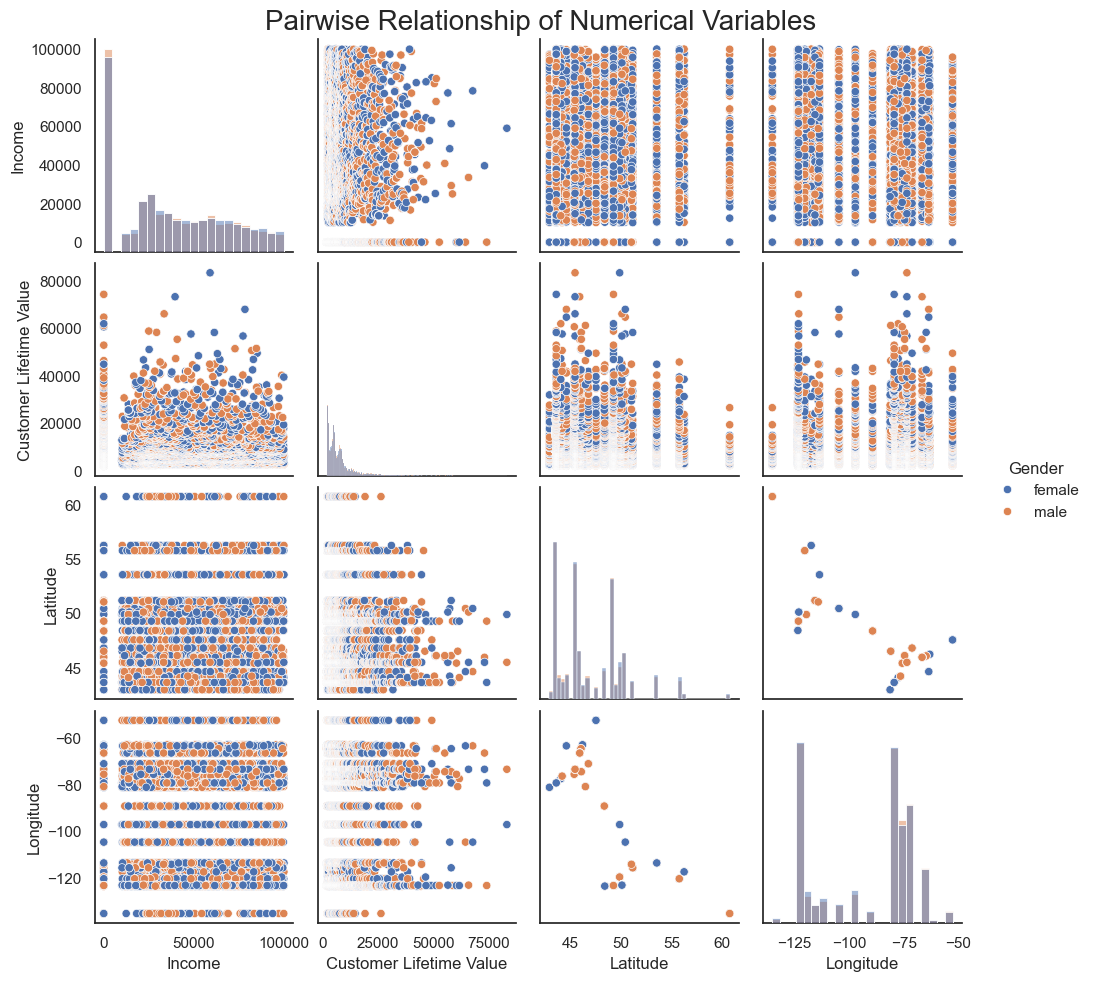

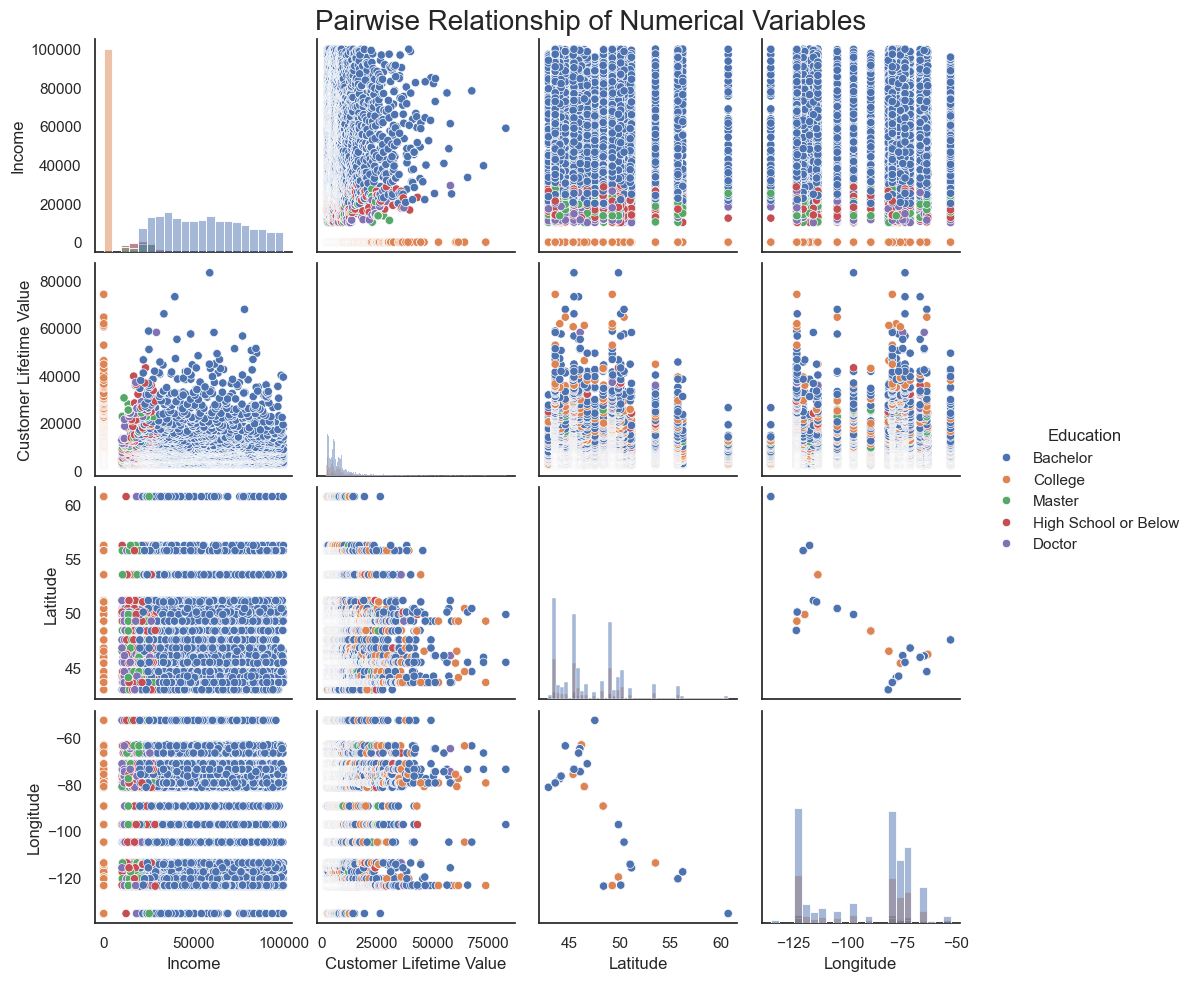

In [ ]:
##### numeric_features_c change ################
sns.set(style="white")
for categories in categorical_features_c[:2]:
    sns.pairplot(
        df_AIAI_Customers[numeric_features_c +[categories]], 
        diag_kind="hist", 
        hue= categories,
        )

    plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)
    plt.subplots_adjust(top=0.95)

plt.show()

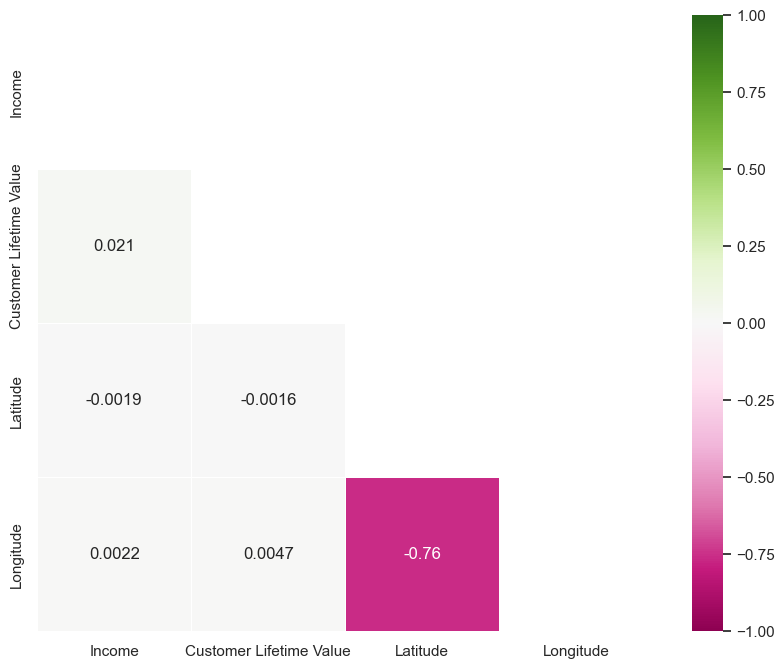

In [81]:
corr = df_AIAI_Customers[numeric_features_c].corr(method="pearson")

fig = plt.figure(figsize=(10, 8))

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

####
sns.heatmap(data=corr, 
            annot=True, 
            mask=mask, #aply the mask
            vmin=-1, vmax=1, 
            center=0, # Center the colormap at zero
            square=True, # Make each cell square-shaped
            linewidths=.5, # Add lines between cells
            cmap='PiYG' # Diverging color map
            )
####

plt.show()